In [1]:
import torch
import timm
import albumentations as A
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"timm version: {timm.__version__}")
print(f"albumentations version: {A.__version__}")

PyTorch: 2.4.1+cu124
CUDA available: True
GPU: NVIDIA A40
timm version: 1.0.26
albumentations version: 1.3.1


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("All imports successful!")

All imports successful!


In [3]:
# Seed 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [4]:
# Paths
DATA_DIR   = "/workspace/melanoma/data"
TRAIN_DIR  = os.path.join(DATA_DIR, "train")
TEST_DIR   = os.path.join(DATA_DIR, "test")
TRAIN_CSV  = os.path.join(DATA_DIR, "train.csv")
MODEL_DIR  = "/workspace/melanoma/models"
OUTPUT_DIR = "/workspace/melanoma/outputs"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
# Hyperparameters 
IMG_SIZE   = 224        # EfficientNet-B0 default
BATCH_SIZE = 32
NUM_EPOCHS = 15
LR         = 1e-4
NUM_WORKERS = 4
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
print(f"Device : {DEVICE}")
print(f"Train  : {TRAIN_DIR}")
print(f"Images : {len(os.listdir(TRAIN_DIR))}")

Device : cuda
Train  : /workspace/melanoma/data/train
Images : 33126


In [7]:
# Loading and exploring the CSV

df = pd.read_csv(TRAIN_CSV)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(df.head(3))
print(f"\nClass distribution:")
print(df['target'].value_counts())
print(f"\nPositive rate: {df['target'].mean()*100:.2f}%")
print(f"\nMissing values:\n{df.isnull().sum()}")

Shape: (33126, 11)

Columns: ['image_name', 'patient_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target', 'tfrecord', 'width', 'height']

First 3 rows:


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,tfrecord,width,height
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0,0,6000,4000
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0,0,6000,4000
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0,6,1872,1053



Class distribution:
target
0    32542
1      584
Name: count, dtype: int64

Positive rate: 1.76%

Missing values:
image_name                         0
patient_id                         0
sex                               65
age_approx                        68
anatom_site_general_challenge    527
diagnosis                          0
benign_malignant                   0
target                             0
tfrecord                           0
width                              0
height                             0
dtype: int64


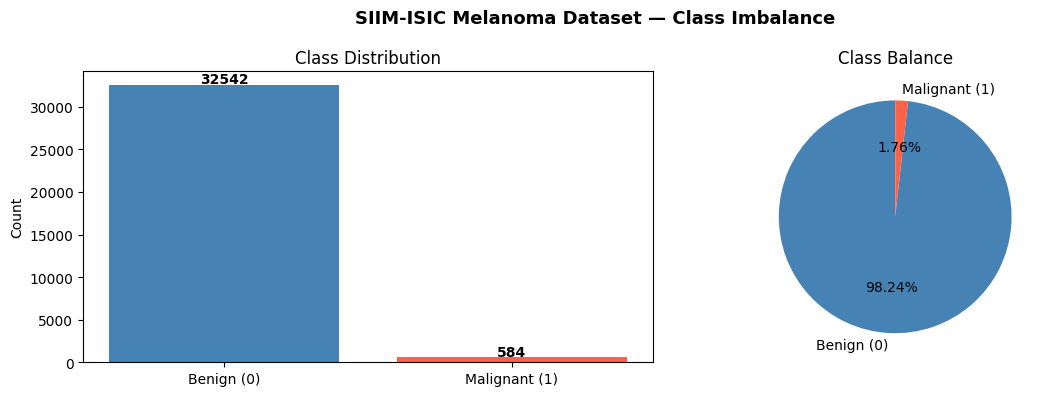

Saved!


In [8]:
# Visuallizing the distributions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Benign (0)', 'Malignant (1)'], 
            df['target'].value_counts().values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['target'].value_counts().values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(df['target'].value_counts().values,
            labels=['Benign (0)', 'Malignant (1)'],
            colors=['steelblue', 'tomato'],
            autopct='%1.2f%%',
            startangle=90)
axes[1].set_title('Class Balance')

plt.suptitle('SIIM-ISIC Melanoma Dataset — Class Imbalance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

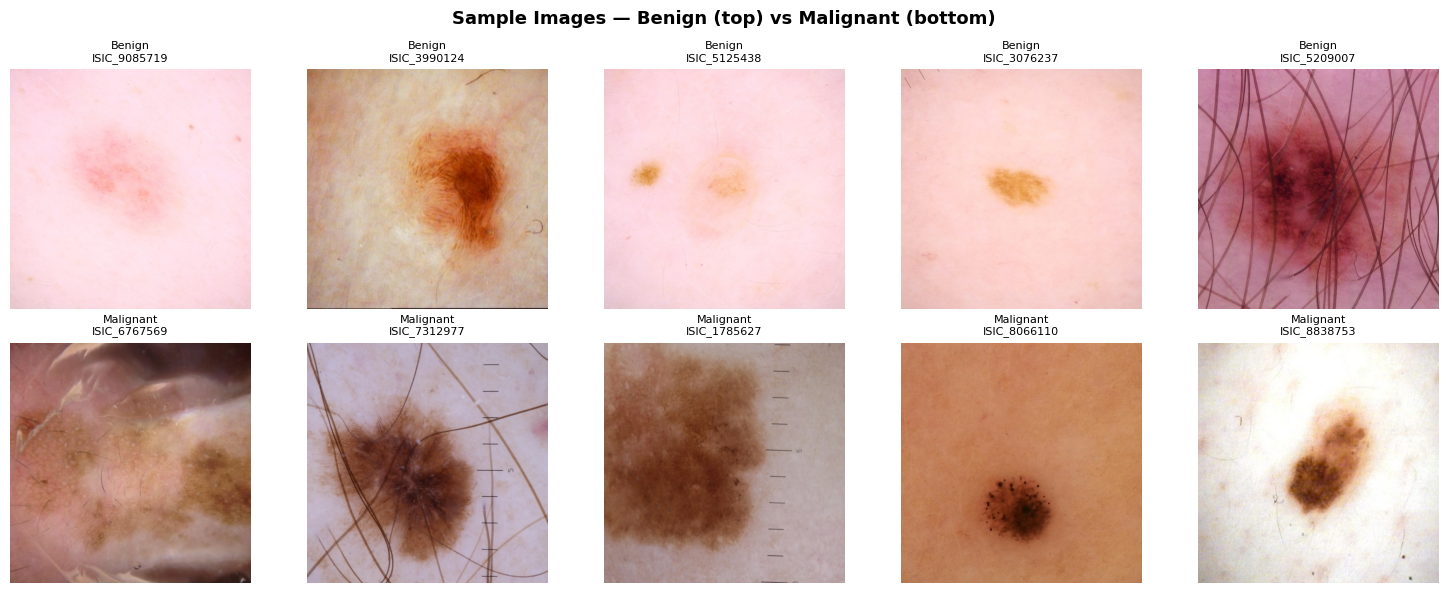

Saved!


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, label in enumerate([0, 1]):
    samples = df[df['target'] == label].sample(5, random_state=SEED)
    for col, (_, sample) in enumerate(samples.iterrows()):
        img_path = os.path.join(TRAIN_DIR, sample['image_name'] + '.jpg')
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(
            f"{'Malignant' if label == 1 else 'Benign'}\n{sample['image_name']}",
            fontsize=8
        )

plt.suptitle('Sample Images — Benign (top) vs Malignant (bottom)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [10]:
# Train validation split 
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=df['target']  # keeps class ratio in both splits
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"\nTrain - Malignant: {train_df['target'].sum()} / {len(train_df)} ({train_df['target'].mean()*100:.2f}%)")
print(f"Val - Malignant: {val_df['target'].sum()} / {len(val_df)} ({val_df['target'].mean()*100:.2f}%)")

Train size: 26500
Val size: 6626

Train - Malignant: 467 / 26500 (1.76%)
Val - Malignant: 117 / 6626 (1.77%)


In [11]:
# Fixing class imbalance with WeightedRandomSampler

# Count samples per class
class_counts = train_df['target'].value_counts().sort_index().values

# Assign weight to each sample (inverse of class frequency)
class_weights = 1.0 / class_counts
sample_weights = train_df['target'].map(lambda x: class_weights[x]).values.copy()  # .copy() fixes the warning

# Create sampler
sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

print(f"Class counts: Benign={class_counts[0]}, Malignant={class_counts[1]}")
print(f"Class weights: Benign={class_weights[0]:.6f}, Malignant={class_weights[1]:.6f}")
print(f"Weight ratio: {class_weights[1]/class_weights[0]:.1f}x more likely to sample malignant")
print(f"Sampler ready: {len(sample_weights)} samples")

Class counts: Benign=26033, Malignant=467
Class weights: Benign=0.000038, Malignant=0.002141
Weight ratio: 55.7x more likely to sample malignant
Sampler ready: 26500 samples


In [12]:
# Transforms

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [13]:
# Dataset class

class MelanomaDataset(Dataset):
    def __init__(self, df, img_dir, transforms=None):
        self.df         = df
        self.img_dir    = img_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_name'] + '.jpg')
        image    = np.array(Image.open(img_path).convert('RGB'))
        label    = torch.tensor(row['target'], dtype=torch.float32)

        if self.transforms:
            image = self.transforms(image=image)['image']

        return image, label

print("Dataset class and transforms defined!")

Dataset class and transforms defined!


In [14]:
# Datasets
train_dataset = MelanomaDataset(train_df, TRAIN_DIR, transforms=train_transforms)
val_dataset   = MelanomaDataset(val_df,   TRAIN_DIR, transforms=val_transforms)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# Sanity check - one batch
images, labels = next(iter(train_loader))
print(f"\nBatch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")
print(f"Labels in batch: {labels.sum().item()} malignant / {BATCH_SIZE} total")

Train batches: 829
Val batches: 208

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Labels in batch: 17.0 malignant / 32 total


In [15]:
# Model class

class MelanomaModel(nn.Module):
    def __init__(self, model_name='efficientnet_b0', pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        in_features   = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

model = MelanomaModel('efficientnet_b0', pretrained=True).to(DEVICE)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params: 4,008,829
Trainable params: 4,008,829


In [16]:
# Loss, Optimizer and Scheduler 

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print(f"Loss: BCEWithLogitsLoss")
print(f"Optimizer: Adam (lr={LR})")
print(f"Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS}, eta_min=1e-6)")

Loss: BCEWithLogitsLoss
Optimizer: Adam (lr=0.0001)
Scheduler: CosineAnnealingLR (T_max=15, eta_min=1e-6)


In [17]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_labels, all_preds = [], []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())

    avg_loss = running_loss / len(loader)
    auc      = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc


def val_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images).squeeze(1)
            loss    = criterion(outputs, labels)

            running_loss += loss.item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())

    avg_loss = running_loss / len(loader)
    auc      = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc

print("Training functions defined!")

Training functions defined!


In [20]:
best_auc    = 0.0
best_epoch  = 0
history     = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_auc = val_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)

    # Save best model
    if val_auc > best_auc:
        best_auc = val_auc
        best_epoch = epoch
        torch.save(model.state_dict(), f"{MODEL_DIR}/effnet_b0_best.pth")
        tag = " | Saved"
    else:
        tag = ""

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}{tag}")

print(f"\nBest Val AUC: {best_auc:.4f} at Epoch {best_epoch}")

Epoch [01/15] Train Loss: 0.1716 | Train AUC: 0.9809 | Val Loss: 0.1412 | Val AUC: 0.8653 | Saved
Epoch [02/15] Train Loss: 0.1247 | Train AUC: 0.9895 | Val Loss: 0.1269 | Val AUC: 0.8882 | Saved
Epoch [03/15] Train Loss: 0.0901 | Train AUC: 0.9942 | Val Loss: 0.1237 | Val AUC: 0.8799
Epoch [04/15] Train Loss: 0.0758 | Train AUC: 0.9959 | Val Loss: 0.1112 | Val AUC: 0.8837
Epoch [05/15] Train Loss: 0.0628 | Train AUC: 0.9971 | Val Loss: 0.1171 | Val AUC: 0.8791
Epoch [06/15] Train Loss: 0.0514 | Train AUC: 0.9982 | Val Loss: 0.1238 | Val AUC: 0.8756
Epoch [07/15] Train Loss: 0.0458 | Train AUC: 0.9986 | Val Loss: 0.1221 | Val AUC: 0.8566
Epoch [08/15] Train Loss: 0.0345 | Train AUC: 0.9991 | Val Loss: 0.1286 | Val AUC: 0.8467
Epoch [09/15] Train Loss: 0.0293 | Train AUC: 0.9994 | Val Loss: 0.1371 | Val AUC: 0.8250
Epoch [10/15] Train Loss: 0.0274 | Train AUC: 0.9994 | Val Loss: 0.1313 | Val AUC: 0.8416
Epoch [11/15] Train Loss: 0.0238 | Train AUC: 0.9996 | Val Loss: 0.1388 | Val AUC: 0

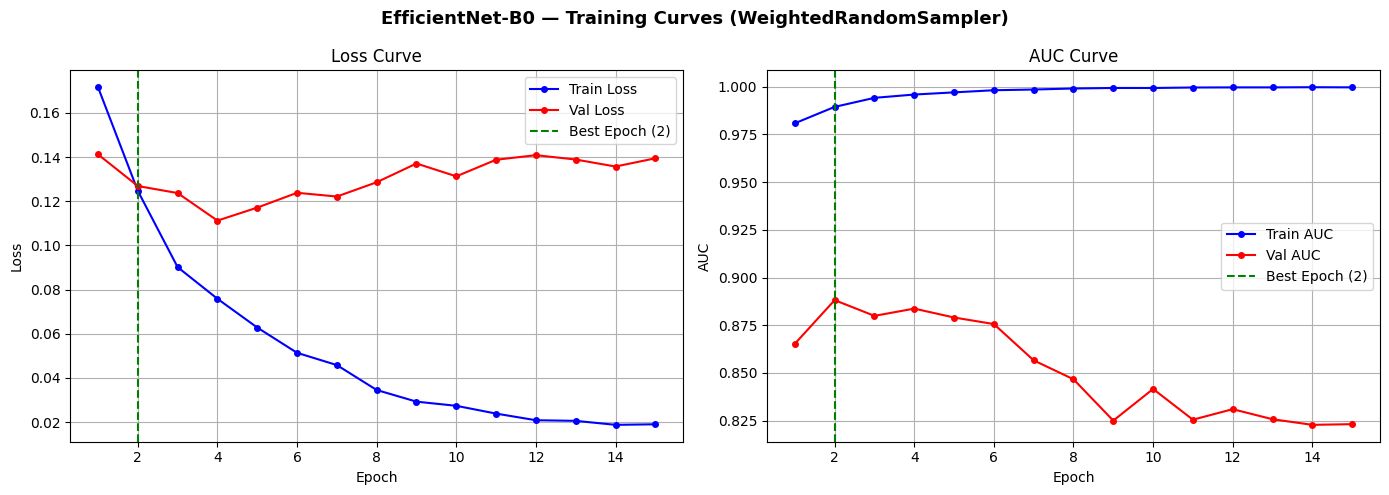

Saved!


In [21]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# AUC
axes[1].plot(epochs, history['train_auc'], 'b-o', label='Train AUC', markersize=4)
axes[1].plot(epochs, history['val_auc'],   'r-o', label='Val AUC',   markersize=4)
axes[1].axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[1].set_title('AUC Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('EfficientNet-B0 — Training Curves (WeightedRandomSampler)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/b0_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [22]:
# Load best model
model.load_state_dict(torch.load(f"{MODEL_DIR}/effnet_b0_best.pth"))
model.eval()

all_labels, all_preds = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(probs)

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Convert probs to binary predictions at threshold 0.5
all_binary = (all_preds >= 0.5).astype(int)

print(f"Val AUC : {roc_auc_score(all_labels, all_preds):.4f}")
print(f"Predictions : {all_binary.sum()} malignant predicted out of {len(all_binary)}")
print(f"Actual : {int(all_labels.sum())} malignant in ground truth")

/tmp/ipykernel_2978/1555726122.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{MODEL_DIR}/effnet_b0_best.pth"))


Val AUC : 0.8882
Predictions : 235 malignant predicted out of 6626
Actual : 117 malignant in ground truth


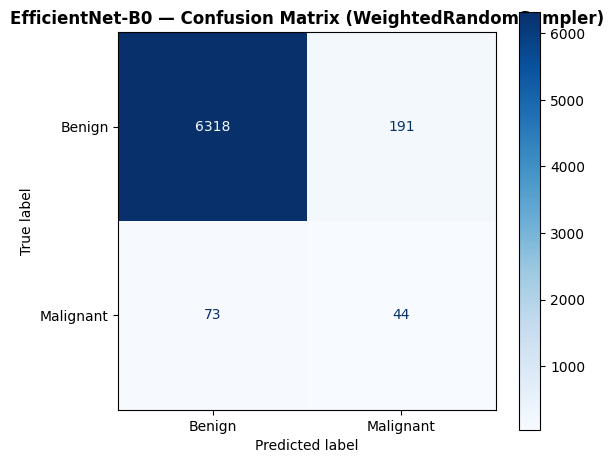


Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.97      0.98      6509
   Malignant       0.19      0.38      0.25       117

    accuracy                           0.96      6626
   macro avg       0.59      0.67      0.61      6626
weighted avg       0.97      0.96      0.97      6626



In [24]:
cm = confusion_matrix(all_labels, all_binary)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('EfficientNet-B0 — Confusion Matrix (WeightedRandomSampler)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/b0_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_binary, target_names=['Benign', 'Malignant']))

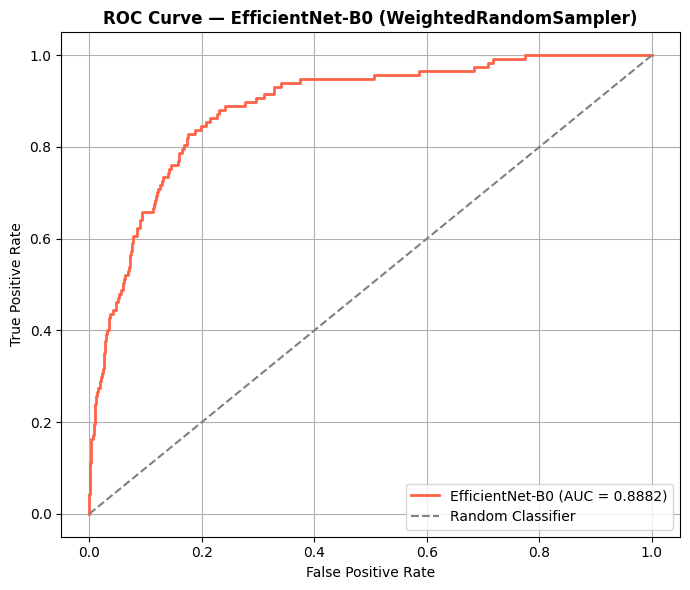

Saved!


In [25]:
# ROC curve

fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
auc_score = roc_auc_score(all_labels, all_preds)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'EfficientNet-B0 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — EfficientNet-B0 (WeightedRandomSampler)', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/b0_roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [26]:
# Testing the model 

test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
print(f"Test samples: {len(test_df)}")
print(test_df.head(3))

Test samples: 10982
     image_name  patient_id     sex  age_approx anatom_site_general_challenge  \
0  ISIC_0052060  IP_3579794    male        70.0                           NaN   
1  ISIC_0052349  IP_7782715    male        40.0               lower extremity   
2  ISIC_0058510  IP_7960270  female        55.0                         torso   

   width  height  
0   6000    4000  
1   6000    4000  
2   6000    4000  


In [ ]:
# Test dataset (no labels)
class MelanomaTestDataset(Dataset):
    def __init__(self, df, img_dir, transforms=None):
        self.df = df
        self.img_dir = img_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_name'] + '.jpg')
        image = np.array(Image.open(img_path).convert('RGB'))
        if self.transforms:
            image = self.transforms(image=image)['image']
        return image

test_dataset = MelanomaTestDataset(test_df, TEST_DIR, transforms=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [29]:
# Load best model and run inference
model.load_state_dict(torch.load(f"{MODEL_DIR}/effnet_b0_best.pth"))
model.eval()

all_preds = []
with torch.no_grad():
    for images in test_loader:
        images = images.to(DEVICE)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_preds.extend(probs)

# Save submission
submission = pd.DataFrame({
    'image_name': test_df['image_name'],
    'target': all_preds
})
submission.to_csv(f"{OUTPUT_DIR}/b0_submission.csv", index=False)

print(f"Predictions generated : {len(all_preds)}")
print(f"\nSample predictions:")
print(submission.head(10))

/tmp/ipykernel_2978/2331524163.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{MODEL_DIR}/effnet_b0_best.pth"))


Predictions generated : 10982

Sample predictions:
     image_name        target
0  ISIC_0052060  1.911211e-04
1  ISIC_0052349  2.283810e-05
2  ISIC_0058510  2.894018e-05
3  ISIC_0073313  3.437692e-07
4  ISIC_0073502  5.820542e-04
5  ISIC_0074618  1.428182e-04
6  ISIC_0076801  4.028604e-06
7  ISIC_0077586  2.186361e-04
8  ISIC_0082004  9.484369e-03
9  ISIC_0082785  5.766682e-06
